In [316]:
from pybaseball import batting_stats, playerid_lookup, playerid_reverse_lookup
import sys
sys.path.append("/Users/briandeng/Documents/func")
import plot
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [317]:
df_2025 = batting_stats(2025)
df_2025 = df_2025[df_2025["G"] >= 50]

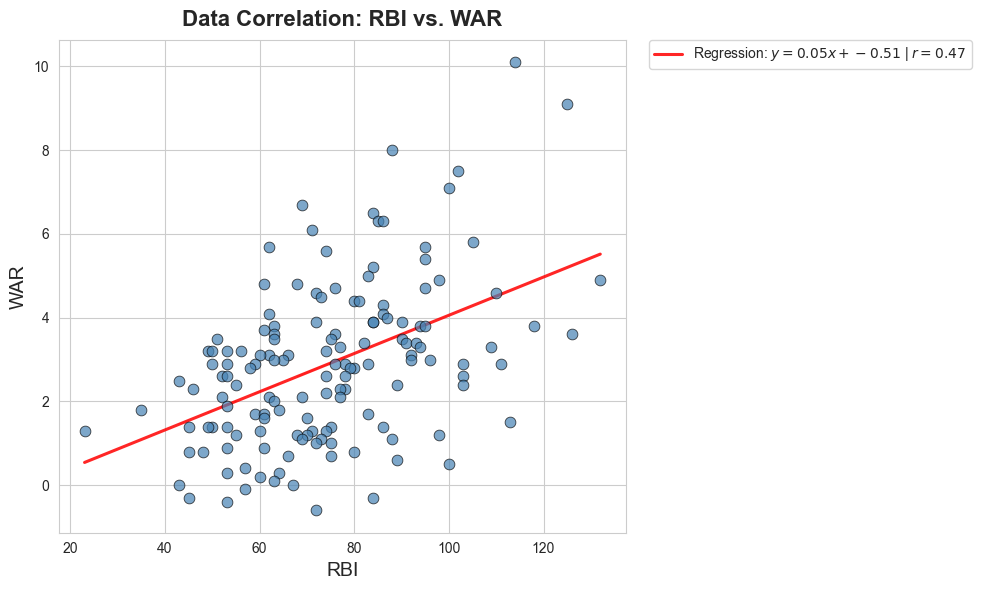

In [318]:
plot.scatter_plot(data=df_2025, x="RBI", y="WAR", corr=True)

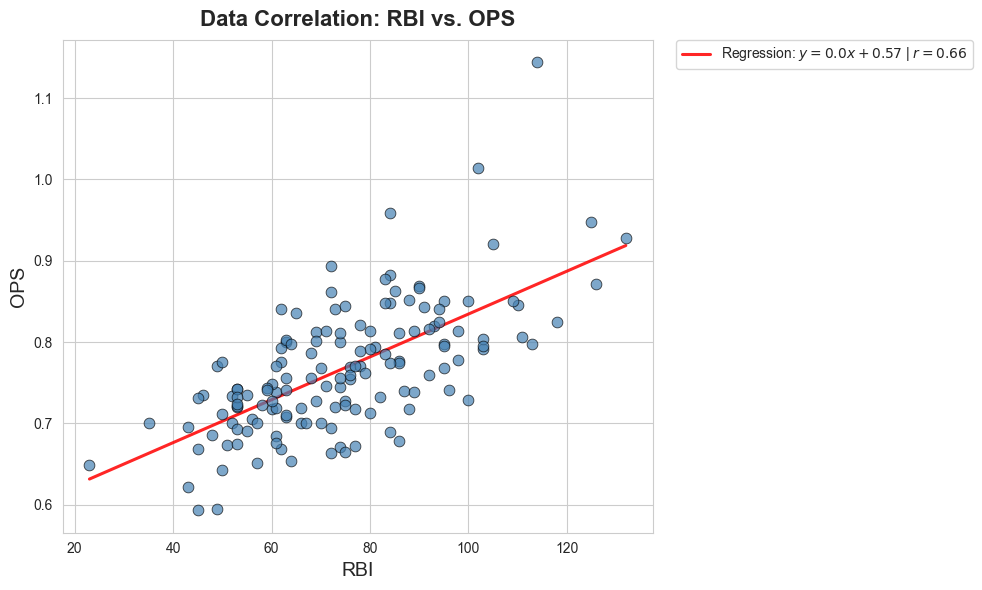

In [319]:
plot.scatter_plot(data=df_2025, x="RBI", y="OPS", corr=True)

In [320]:
# read data with result
result_df = pd.read_parquet("data_with_result.parquet")

In [321]:
# group by data
group_result_df = result_df.groupby("batter", as_index=False)["RBI"].sum()

In [322]:
# get all FanGraphs IDs from df_2025
fg_ids = df_2025['IDfg'].unique().tolist()

# lookup table: FanGraphs ID → Statcast ID
lookup = playerid_reverse_lookup(fg_ids, key_type='fangraphs')

# merge lookup into your dataframe
df_2025 = df_2025.merge(
    lookup[['key_fangraphs', 'key_mlbam']],
    left_on='IDfg',
    right_on='key_fangraphs',
    how='left'
)

# rename to batter
df_2025 = df_2025.rename(columns={'key_mlbam': 'batter'})

# remove extra column
df_2025 = df_2025.drop(columns=['key_fangraphs'])

In [323]:
batter_lst = df_2025[df_2025["G"] >= 30]["batter"]

In [324]:
group_result_df[group_result_df["batter"].isin(batter_lst)]["RBI"].mean()

np.float64(76.18796992481202)

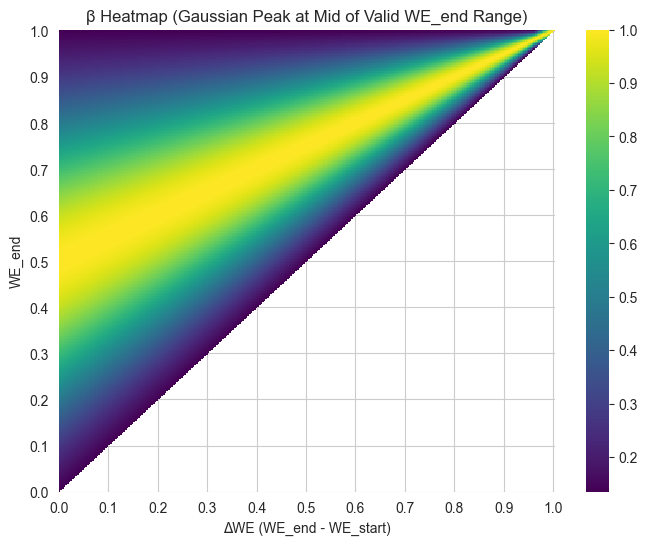

In [325]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ΔWE only positive
we_delta = np.linspace(0, 1, 300) 
we_end   = np.linspace(0, 1, 300)

# Grid
DELTA, END = np.meshgrid(we_delta, we_end)

# Validity condition: WE_start = END - DELTA ∈ [0,1]
START = END - DELTA
invalid_mask = (START < 0) | (START > 1)

# Beta parameters:
# Peak (Gaussian mean) at midpoint of valid WE_end range
mu = (DELTA + 1) / 2

# Width (sigma shrinks as ΔWE grows)
sigma = (1 - DELTA) / 4
sigma[sigma < 0.01] = 0.01    # avoid zero division

# Gaussian beta
beta = np.exp(-((END - mu)**2) / (2 * sigma**2))

# Mask invalid region
beta_masked = np.ma.array(beta, mask=invalid_mask)

# Plot heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    beta_masked,
    cmap="viridis",
    mask=invalid_mask,
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

# Proper axis ticks
x_ticks = np.linspace(0, len(we_delta)-1, 11)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.1f}" for v in np.linspace(0, 1, 11)])

y_ticks = np.linspace(0, len(we_end)-1, 11)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0, 1, 11)])

# Standard y-axis (0 bottom → 1 top)
ax.invert_yaxis()

plt.xlabel("ΔWE (WE_end - WE_start)")
plt.ylabel("WE_end")
plt.title("β Heatmap (Gaussian Peak at Mid of Valid WE_end Range)")

plt.show()

In [326]:
# define delta we
delta_we = np.arange(-1, 1 + 0.01, 0.02)

# define f1
f1 = 2 * ((delta_we + 1) / 2) ** 3

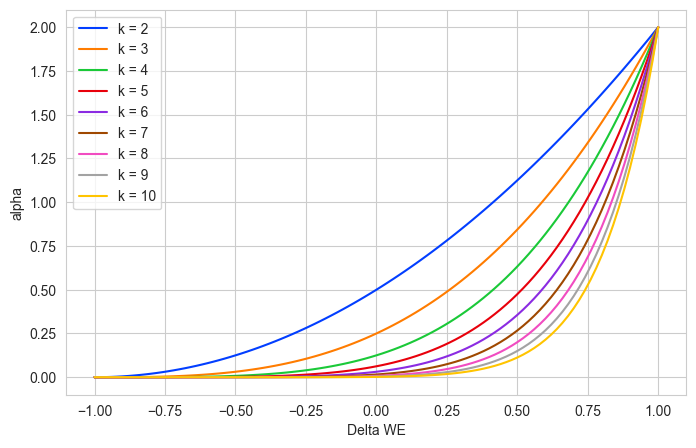

In [327]:
# plot power function
k_lst = range(2, 11)

fig = plt.figure(figsize=(8, 5))

for k in k_lst:
    y = 2 * ((delta_we + 1) / 2) ** k
    sns.lineplot(x=delta_we, y=y, label=f"k = {k}")

plt.xlabel("Delta WE")
plt.ylabel("alpha")
plt.show()

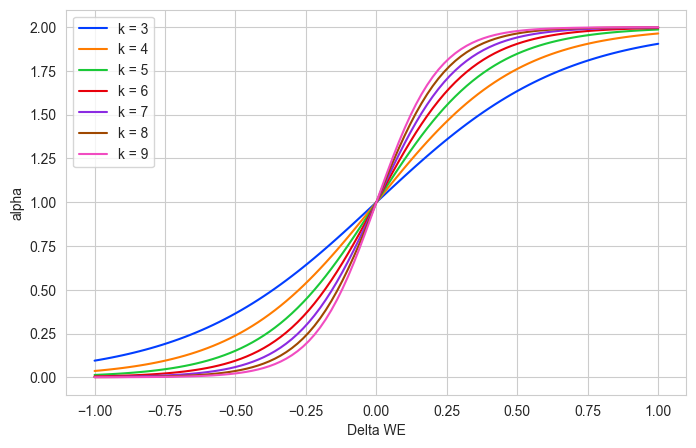

In [328]:
# plot exponential function
k_lst = range(3, 10)

fig = plt.figure(figsize=(8, 5))

for k in k_lst:
    y = 2 / (1 + np.exp(-k * delta_we))
    sns.lineplot(x=delta_we, y=y, label=f"k = {k}")

plt.xlabel("Delta WE")
plt.ylabel("alpha")
plt.show()

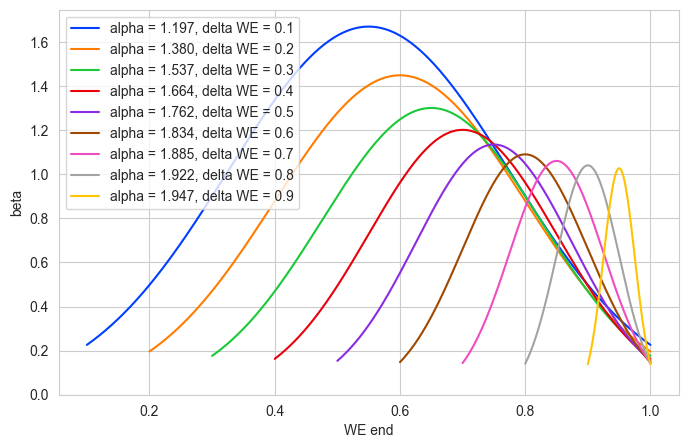

In [329]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp
import seaborn as sns

# beta function
def beta_func(a, b, alpha):
    mu = (1 + a) / 2

    # domain of b is [a, 1]
    # correct sigma to fit domain
    sigma = min((mu - a) / 2, (1 - mu) / 2)

    # scaled normal-shaped value
    beta = (2 / alpha) * np.exp(-((b - mu) ** 2) / (2 * sigma ** 2))
    return beta


# plot beta curves
delta_we_lst = np.arange(0.1, 1, 0.1)

fig = plt.figure(figsize=(8, 5))

for delta_we in delta_we_lst:
    # alpha = 2 * ((delta_we + 1) / 2) ** 3
    alpha = 2 / (1 + np.exp(-4 * delta_we))
    we_end_lst = np.arange(delta_we, 1 + 0.001, 0.001)

    beta_lst = [beta_func(delta_we, b, alpha) for b in we_end_lst]

    sns.lineplot(x=we_end_lst, y=beta_lst, label=f"alpha = {alpha:.3f}, delta WE = {delta_we:.1f}")

plt.ylim(0, None)
plt.xlabel("WE end")
plt.ylabel("beta")
plt.show()


In [330]:
result_df.describe()

,batter,RBI,ARBI1,CRBI1,delta_WE,WE_end,alpha1,beta1
count,16182.0,16182.0,16182.0,16182.0,16182.000000,16182.000000,16182.000000,16182.000000
mean,654130.655296,1.299345,1.562893,1.321376,0.093286,0.672454,1.176857,0.877992
std,50465.265956,0.587132,0.862014,0.954852,0.091130,0.283685,0.157994,0.514479
min,455117.0,1.0,0.611527,0.270671,-0.205000,0.000000,0.611527,0.138974
25%,642136.0,1.0,1.061921,0.545876,0.021913,0.538000,1.043799,0.364400
50%,666310.0,1.0,1.199297,1.168437,0.085000,0.724000,1.168381,0.801782
75%,681297.0,1.0,1.538471,1.863038,0.129000,0.915000,1.252424,1.360940
max,810938.0,4.0,7.655142,7.993851,0.904000,1.000000,1.947628,2.905762


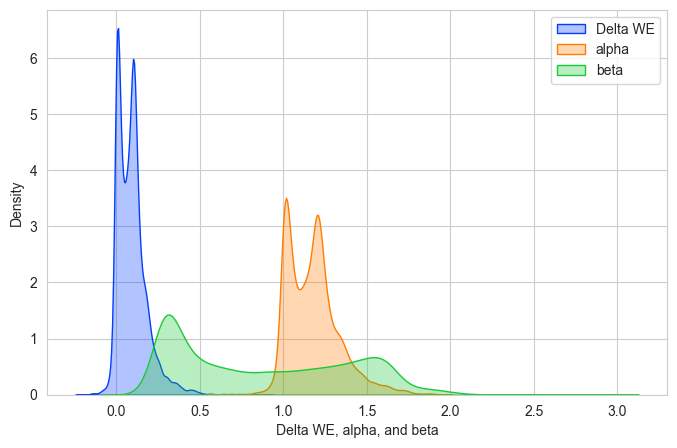

In [331]:
fig = plt.figure(figsize=(8, 5))
sns.kdeplot(data=result_df, x="delta_WE", fill=True, alpha=0.3, bw_adjust=1.0, label="Delta WE")
sns.kdeplot(data=result_df, x="alpha1", fill=True, alpha=0.3, bw_adjust=1.0, label="alpha")
sns.kdeplot(data=result_df, x="beta1", fill=True, alpha=0.3, bw_adjust=1.0, label="beta")
plt.xlabel("Delta WE, alpha, and beta")
plt.legend()

In [332]:
group_df = result_df.groupby(by="batter_name", as_index=False).agg({
    "RBI": "sum",
    "ARBI1": "sum",
    "CRBI1": "sum",
    "batter": "first"
})

In [ ]:
# keep RBI with at east 30
group_df = group_df[group_df["RBI"] >= 30]
group_df["ARBI"], group_df["CRBI"] = group_df["ARBI1"], group_df["CRBI1"]
group_df = group_df[["batter", "batter_name", "RBI", "ARBI", "CRBI"]]

In [334]:
# add change rate
group_df["ARBI rate"] = group_df["ARBI"] / group_df["RBI"]
group_df["CRBI rate"] = group_df["CRBI"] / group_df["RBI"]

In [335]:
group_df.sort_values(by="RBI", ascending=False).head(10)

,batter,batter_name,RBI,ARBI,CRBI,ARBI rate,CRBI rate
355,656941,kyle schwarber,131,159.633357,127.460161,1.218575,0.972978
91,663728,cal raleigh,129,160.666314,123.838528,1.245475,0.959989
479,624413,pete alonso,124,153.953306,138.306752,1.241559,1.115377
190,553993,eugenio suárez,119,152.621255,133.305439,1.282532,1.120214
580,686469,vinnie pasquantino,116,141.745867,127.418292,1.221947,1.098434
0,592450,aaron judge,114,134.155008,113.955782,1.176798,0.999612
493,682985,riley greene,113,136.382951,99.83459,1.206929,0.883492
332,691406,junior caminero,109,129.490992,96.136043,1.187991,0.881982
481,646240,rafael devers,108,129.368774,106.264714,1.197859,0.983933
329,665742,juan soto,108,129.614213,116.048416,1.200132,1.074522


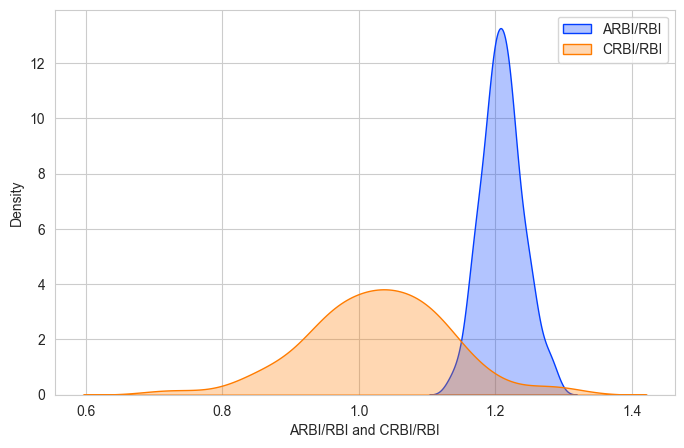

In [336]:
fig = plt.figure(figsize=(8, 5))
sns.kdeplot(data=group_df, x="ARBI rate", fill=True, alpha=0.3, bw_adjust=1.0, label="ARBI/RBI")
sns.kdeplot(data=group_df, x="CRBI rate", fill=True, alpha=0.3, bw_adjust=1.0, label="CRBI/RBI")
plt.xlabel("ARBI/RBI and CRBI/RBI")
plt.legend()

In [340]:
group_df.sort_values(by="ARBI rate", ascending=False).head(10)

,batter,batter_name,RBI,ARBI,CRBI,ARBI rate,CRBI rate
554,663757,trent grisham,78,100.288684,78.686825,1.285752,1.008805
190,553993,eugenio suárez,119,152.621255,133.305439,1.282532,1.120214
511,656811,ryan o'hearn,64,81.8021,72.62753,1.278158,1.134805
284,666176,jo adell,97,123.92957,122.21842,1.277624,1.259984
394,668901,mark vientos,62,78.671532,66.689741,1.268896,1.075641
399,656305,matt chapman,61,77.16803,61.65916,1.26505,1.010806
539,621493,taylor ward,106,133.426487,124.490266,1.25874,1.174436
308,593871,jorge polanco,76,95.641217,82.435865,1.258437,1.084682
235,671056,iván herrera,68,85.392474,78.44357,1.255772,1.153582
442,663993,nathaniel lowe,84,105.325509,96.65904,1.253875,1.150703


In [341]:
group_df.sort_values(by="CRBI rate", ascending=False).head(10)

,batter,batter_name,RBI,ARBI,CRBI,ARBI rate,CRBI rate
326,608070,josé ramírez,84,105.277246,109.69983,1.253301,1.30595
614,687263,zach neto,62,74.906488,80.149319,1.208169,1.292731
597,642715,willy adames,86,102.335678,109.576245,1.18995,1.274142
284,666176,jo adell,97,123.92957,122.21842,1.277624,1.259984
387,672580,maikel garcía,72,87.393282,87.073642,1.213796,1.209356
198,518692,freddie freeman,92,113.906195,110.263179,1.238111,1.198513
89,621439,byron buxton,84,101.317944,99.998186,1.206166,1.190455
539,621493,taylor ward,106,133.426487,124.490266,1.25874,1.174436
354,700932,kyle manzardo,66,80.778978,77.085885,1.223924,1.167968
342,606466,ketel marte,74,91.639676,86.356808,1.238374,1.166984
